## 5. 

Github repo link: https://github.com/kd00250/COMP3800 

In [1]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('export.csv')

## 1. Describing the data

This dataset is published by Montgomery County, Maryland. The dataset is very recent as it was last updated September 5, 2026. The dataset consists of the warehouse and retail sales and product movement by item and department and is updated monthly. The products tracked in this dataset are non-alcoholic and alcoholic beverages categorized in different beverage types such as wine, beer, non-alcoholic, and kegs. These beverages can be further classified by supplier and unique item code. 

The data shows the warehouse sales and movement of cases per product in a certain year and month. These sales and product movements are divided into 3 categories: retail sales, retail transfers, and warehouse sales. Retail sales are sales made in actual retail stores. Retail transfers are products that are moved from the warehouse to the retail stores to be put up for sale. Warehouse sales are products sold to other third party licensed buyers such as restaurants, bars, and other retailers. The dataset and its contents can be found at the following URL: https://catalog.data.gov/dataset/warehouse-and-retail-sales?from_hint=eyJzb3J0IjoicG9wdWxhcml0eSJ9.   

## 1. Problem statements and sub-questions

This dataset of medium size consisting of over 300,000 entries. These entries span years dating all the way back to 2017. This wide range of sales and product data makes this dataset valuable. With this dataset, the publisher can identify trends and changes over the years. These changes can be useful for increasing sales and make the company more profit. To be able to increase sales, one must understand the most popular type of beverage over the years and identify a trend in sales over the years and that is why it is important to analyze the sales trends over time for the beverage categories. While this dataset has entries spanning all the way back to 2017, many of the years are left with missing months. Because of this, I have chosen to analysis the year with the most complete data entries. That year is 2019 as it has data entries for all months except for december.

The main question I aim to answer is an analysis of the overall sales trend of the dataset throughout the year 2019 (Jan - Nov).

This main question can be split further into 3 sub-questions, with those being: 
    
    - What is the top beverage within each category?
    - What is the most sold category over time?
    - How do retail sales and warehousre sales change over time?

In [2]:
print(df.shape)

(341037, 9)


In [3]:
print(df.head())

   YEAR  MONTH       SUPPLIER ITEM CODE  \
0  2026      8  20705 IMPORTS    171162   
1  2026      8  20705 IMPORTS    180424   
2  2026      8  20705 IMPORTS    180363   
3  2026      8  20705 IMPORTS    171163   
4  2026      8      AFARO LLC    246496   

                         ITEM DESCRIPTION ITEM TYPE RETAIL SALES  \
0                     PROSECCO 84 - 750ML      WINE         0.00   
1        FENTO BICO DA RAN ALBARINO 750ML      WINE         0.00   
2          CAN' LEANDRO LES FINQUES 750ML      WINE         0.00   
3   BENNATI CASTELLANO PINOT GRIGIO 750ML      WINE         0.00   
4  CONDE DE TRESAGUAS TEMPRANILLO - 750ML      WINE         0.00   

  RETAIL TRANSFERS WAREHOUSE SALES  
0             0.00            7.00  
1             0.00            1.00  
2             0.00            1.00  
3             0.00           10.00  
4             0.00            1.00  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341037 entries, 0 to 341036
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   YEAR              341037 non-null  int64 
 1   MONTH             341037 non-null  int64 
 2   SUPPLIER          340833 non-null  object
 3   ITEM CODE         341037 non-null  object
 4   ITEM DESCRIPTION  341037 non-null  object
 5   ITEM TYPE         341036 non-null  object
 6   RETAIL SALES      341031 non-null  object
 7   RETAIL TRANSFERS  341037 non-null  object
 8   WAREHOUSE SALES   341037 non-null  object
dtypes: int64(2), object(7)
memory usage: 23.4+ MB


## 2a. Drop unwanted features

In [5]:
#2a. drop unwanted features

df_drop_unwanted_features = df.drop(columns=["RETAIL TRANSFERS"]);

## 2b. Check and address missing values

In [6]:
#2b Check and address missing values

print(df_drop_unwanted_features.isnull().sum())

df_drop_unwanted_features["SUPPLIER"] = df_drop_unwanted_features["SUPPLIER"].fillna("UNKNOWN")
df_drop_unwanted_features["ITEM TYPE"] = df_drop_unwanted_features["ITEM TYPE"].fillna("OTHER")

sales_columns = ["RETAIL SALES", "WAREHOUSE SALES"]

df_cleaned_nulls = df_drop_unwanted_features.dropna(subset=sales_columns)

#I have chosen to remove the 2026 year sales as it is not continueous as there is a gap in sales from 2017 - 2020
df_cleaned_nulls = df_cleaned_nulls[
    df_cleaned_nulls["YEAR"] != 2026
].copy()

YEAR                  0
MONTH                 0
SUPPLIER            204
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          6
WAREHOUSE SALES       0
dtype: int64


## 2c Check for duplicates

In [7]:
#2c Check for duplicates 

print("Number of duplicates: ", df_cleaned_nulls.duplicated().sum())

df_cleaned_duplicates = df_cleaned_nulls.copy()

Number of duplicates:  0


## 2d. Check and correct data types

In [8]:
#2d check and correct data types

print("Data types before cleaning:")
print(df_cleaned_duplicates.dtypes)

df_cleaned_duplicates = df_cleaned_duplicates.copy()

def clean_sales_column(column):
    column = column.astype("string").str.strip()

    # Check for accounting-style values less than 0 such as (0.17)
    is_negative = column.str.match(r"^\(.*\)$", na=False)

    # Remove commas and parentheses
    column = column.str.replace(",", "", regex=False)
    column = column.str.replace("(", "", regex=False)
    column = column.str.replace(")", "", regex=False)

    # Convert the column to numeric
    column = pd.to_numeric(column, errors="coerce")

    # Convert values originally in parentheses to negative numbers
    column.loc[is_negative] = -column.loc[is_negative].abs()

    return column

Data types before cleaning:
YEAR                 int64
MONTH                int64
SUPPLIER            object
ITEM CODE           object
ITEM DESCRIPTION    object
ITEM TYPE           object
RETAIL SALES        object
WAREHOUSE SALES     object
dtype: object


In [9]:
#2d check and correct data types

sales_columns = [
    "RETAIL SALES",
    "WAREHOUSE SALES"
]

for column in sales_columns:
    df_cleaned_duplicates[column] = clean_sales_column(
        df_cleaned_duplicates[column]
    )


df_cleaned_duplicates["YEAR"] = df_cleaned_duplicates["YEAR"].astype(int)
df_cleaned_duplicates["MONTH"] = df_cleaned_duplicates["MONTH"].astype(int)

df_cleaned_duplicates["SUPPLIER"] = (
    df_cleaned_duplicates["SUPPLIER"].astype("string")
)

df_cleaned_duplicates["ITEM DESCRIPTION"] = (
    df_cleaned_duplicates["ITEM DESCRIPTION"].astype("string")
)

df_cleaned_duplicates["ITEM CODE"] = (
    df_cleaned_duplicates["ITEM CODE"].astype("string")
)

df_cleaned_duplicates["ITEM TYPE"] = (
    df_cleaned_duplicates["ITEM TYPE"].astype("string")
)


print("\nData types after cleaning:")
print(df_cleaned_duplicates.dtypes)


Data types after cleaning:
YEAR                         int64
MONTH                        int64
SUPPLIER            string[python]
ITEM CODE           string[python]
ITEM DESCRIPTION    string[python]
ITEM TYPE           string[python]
RETAIL SALES               Float64
WAREHOUSE SALES            Float64
dtype: object


## 2e. Check categorical variables for inconsistent inputs

In [10]:
#2e check categorical variables for inconsistent inputs

categorical_columns = ["SUPPLIER", "ITEM CODE", "ITEM TYPE"]

for column in categorical_columns:
    print("\n", column)
    print(df_cleaned_duplicates[column].value_counts().head(20))


 SUPPLIER
SUPPLIER
REPUBLIC NATIONAL DISTRIBUTING CO       20995
LEGENDS LTD                             13634
SOUTHERN GLAZERS WINE AND SPIRITS       11720
E & J GALLO WINERY                      10816
THE COUNTRY VINTNER, LLC DBA WINEBOW    10669
MONSIEUR TOUTON SELECTION               10360
A VINTNERS SELECTIONS                    9994
BACCHUS IMPORTERS LTD                    9150
DIAGEO NORTH AMERICA INC                 7520
RELIABLE CHURCHILL LLLP                  6971
CONSTELLATION BRANDS                     6684
JIM BEAM BRANDS CO                       5993
ANHEUSER BUSCH INC                       5835
DOPS INC                                 5265
PERNOD RICARD USA LLC                    5141
PRESTIGE BEVERAGE GROUP OF MD LLC        5100
OPICI FAMILY DISTRIBUTING OF MD          4997
CONSTANTINE WINES INC                    4932
SAZERAC CO                               4393
DIONYSOS IMPORTS INC                     4181
Name: count, dtype: Int64

 ITEM CODE
ITEM CODE
10271     24

In [11]:
#2e check categorical variables for inconsistent inputs
print(
    df_cleaned_nulls.groupby("YEAR")["MONTH"]
    .unique()
)

YEAR
2017               [12, 11, 10, 9, 8, 7, 6]
2018                                 [2, 1]
2019    [11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
2020                           [9, 7, 3, 1]
Name: MONTH, dtype: object


The dataset contains noticable gaps, skipping multiple months and whole years. For this reason I have chosen to analyze the year 2019 as it is the most complete year having 11 out of 12 months

## 2f. Check numeric variables for outliers

In [12]:
#2f check numeric variables for outliers

sales_columns = [
    "RETAIL SALES",
    "WAREHOUSE SALES"
]

for column in sales_columns:
    q1 = df_cleaned_duplicates[column].quantile(0.25)
    median = df_cleaned_duplicates[column].median()
    q3 = df_cleaned_duplicates[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df_cleaned_duplicates[
        (df_cleaned_duplicates[column] < lower_bound) |
        (df_cleaned_duplicates[column] > upper_bound)
    ]
    
    print(column)
    print("Q1:", q1)
    print("Median:", median)
    print("Q3:", q3)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of possible outliers:", len(outliers))
    print()

print("All outliers are kept because they are not found to be entry errors and are actual sales or returns.")

RETAIL SALES
Q1: 0.0
Median: 0.32
Q3: 3.2675
Lower bound: -4.90125
Upper bound: 8.16875
Number of possible outliers: 48014

WAREHOUSE SALES
Q1: 0.0
Median: 1.0
Q3: 5.0
Lower bound: -7.5
Upper bound: 12.5
Number of possible outliers: 44156

All outliers are kept because they are not found to be entry errors and are actual sales or returns.


## Exploratory Data Analysis and Interpretation of Question 1

In [13]:
#3a process question 1
beverage_types = [
    "BEER",
    "KEGS",
    "LIQUOR",
    "NON-ALCOHOL",
    "WINE"
]

#Create the data frame with just 2019 data which is the most consistent time frame
df_2019 = df_cleaned_duplicates[
    df_cleaned_duplicates["YEAR"] == 2019
].copy()

beverage_data_2019 = df_2019[
    df_2019["ITEM TYPE"].isin(beverage_types)
].copy()

beverage_data_2019["TOTAL SALES"] = (
    beverage_data_2019["RETAIL SALES"]
    + beverage_data_2019["WAREHOUSE SALES"]
)

product_sales = (
    beverage_data_2019
    .groupby(
        ["ITEM TYPE", "ITEM CODE", "ITEM DESCRIPTION"]
    )["TOTAL SALES"]
    .sum()
    .reset_index()
)

print(product_sales)
print()

      ITEM TYPE ITEM CODE                                   ITEM DESCRIPTION  \
0          BEER      1001              SAM SMITH ORGANIC PEAR CIDER - 18.7OZ   
1          BEER     10014              SAM SMITH GIFT PACK W/ GLASS - 18.7OZ   
2          BEER      1002                     TRAQUAIR JACOBITE ALE - 16.9OZ   
3          BEER      1004                                LEO BEER - THAILAND   
4          BEER      1008  JACK DANIELS COUNTRY COCKTAIL SOUTHERN PEACH -...   
...         ...       ...                                                ...   
23928      WINE     93020                        BENZIGER CHARD 2017 - 750ML   
23929      WINE     96069                                   BEX RIES - 750ML   
23930      WINE    995692                           FINCA DECERO CAB - 750ML   
23931      WINE     99684                    DANSK VIKING BLOOD MEAD - 750ML   
23932      WINE     99693                              DANSK GI MJOD - 25.4Z   

       TOTAL SALES  
0            26.97

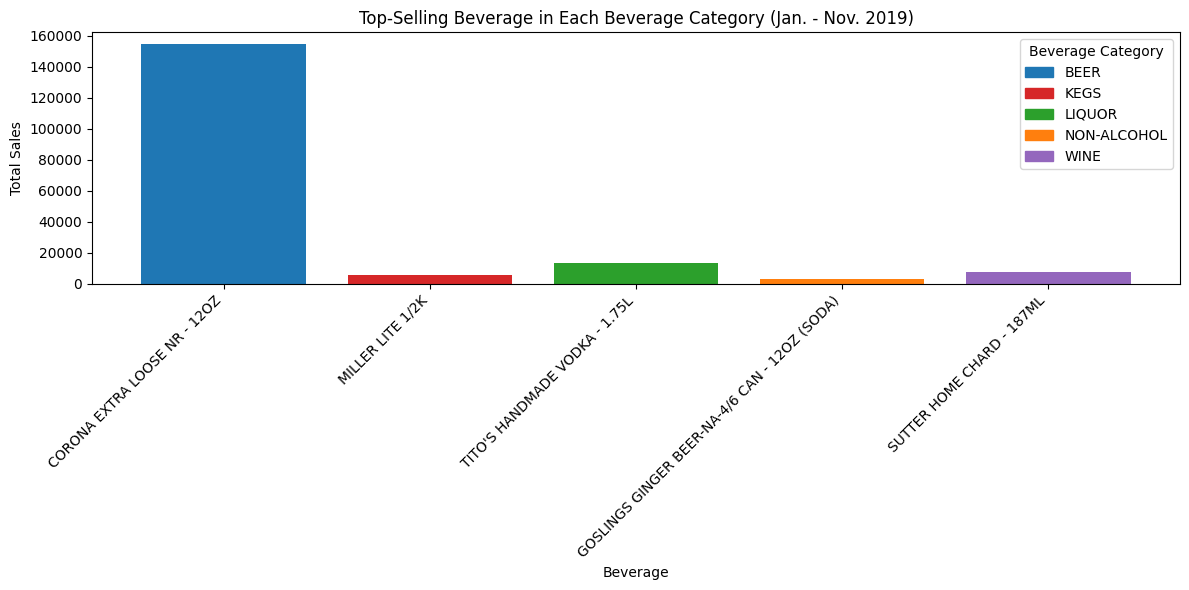

In [14]:
#3b question 1
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


category_colors = {
    "BEER": "tab:blue",
    "KEGS": "tab:red",
    "LIQUOR": "tab:green",
    "NON-ALCOHOL": "tab:orange",
    "WINE": "tab:purple"}

top_beverages = product_sales.loc[
    product_sales.groupby("ITEM TYPE")["TOTAL SALES"].idxmax()
]

bar_colors = top_beverages["ITEM TYPE"].map(category_colors)

plt.figure(figsize=(12, 6))

plt.bar(
    top_beverages["ITEM DESCRIPTION"],
    top_beverages["TOTAL SALES"],
    color=bar_colors
)

plt.title("Top-Selling Beverage in Each Beverage Category (Jan. - Nov. 2019)")
plt.xlabel("Beverage")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

legend_items = [
    Patch(color=color, label=category)
        for category, color in category_colors.items()]

plt.legend(
    handles=legend_items,
    title="Beverage Category")

plt.tight_layout()
plt.show()

# 3c Question 1 Interpretation.

The bar graph shows the top selling beverages for each category in the year 2019 from the months January - November. These total sales where calculated from combining the retail and warehouse sales per product. The top selling beer was 12 ounce bottle of corona extra loose, selling almost 160,000. The most popular keg was the 1/2 (15.5 gallons) miller lite keg selling about 5,000. The top selling liquor was the 1.75 liter bottle of tito's homemade vodka having around 10,000 in sales. The top selling non-alcoholic drink was the 12 ounce goslings ginger beer with around 2,500 in sales. The most popular wine was 187 milliliter bottle of sutter home chard with about 7,000 in sales. 

This bar chart shows that beer has a clear dominance in popularity in comparison to the rest of the  beverage categories. The most popular beer is shown to have over ten times the amount of sales than any other of the most popular beverages. The chart shows that the most popular beer's size is in a 12 ounce bottle. The chart also shows that the most popular keg's size is a full size keg (15.5 gallons). The the most popular vodka's size is reported to be a 1.75 liter bottle. The most popular non-alcoholic beverage's size is also reported to be a 12 ounce can. The most popular wine's size is reported to be a 187 milliliter or roughly 6 ounce bottle. Overall, this chart shows that smaller bottles are more popular across all beverage categories with 12 ounces and 187 milliliters (roughly 6 ounces) bottles making up a large part of the most popular beverage sales. 

## Exploratory Data Analysis and Interpretation of Question 2

In [15]:
#Process Question 2

# Calculate total actual sales
beverage_data_2019["TOTAL SALES"] = (
    beverage_data_2019["RETAIL SALES"]
    + beverage_data_2019["WAREHOUSE SALES"]
)

# Combine YEAR and MONTH into a date
beverage_data_2019["DATE"] = pd.to_datetime(
    dict(
        year=beverage_data_2019["YEAR"],
        month=beverage_data_2019["MONTH"],
        day=1
    )
)

# Add together all product sales within each category for each month
category_sales_over_time = (
    beverage_data_2019
    .groupby(["DATE", "ITEM TYPE"])["TOTAL SALES"]
    .sum()
    .reset_index()
)

category_sales_pivot = category_sales_over_time.pivot(
    index="DATE",
    columns="ITEM TYPE",
    values="TOTAL SALES"
)

print(category_sales_pivot)
print()

ITEM TYPE        BEER    KEGS    LIQUOR  NON-ALCOHOL      WINE
DATE                                                          
2019-01-01   249315.2  4573.0  33140.12      1992.07  73807.69
2019-02-01  219495.41  4435.0  33421.43      1863.43   74362.3
2019-03-01   260583.3  5600.0  36653.08      2130.88  78316.54
2019-04-01  266993.66  5217.0  34203.73      2005.27  76638.46
2019-05-01  349431.46  5860.0  39991.64      2557.68  86360.29
2019-06-01  321406.58  5358.0  38519.35      2416.08   74628.3
2019-07-01  351239.19  5355.0   37626.2      2684.42  74810.54
2019-08-01  331308.41  5267.0  38126.28      2554.28  75881.62
2019-09-01  293017.22  4951.0   34502.2      2020.25  70966.39
2019-10-01  312170.69  5650.0  38252.64      2875.31  85402.59
2019-11-01   268605.3  4811.0  42121.38      3017.97  87253.07



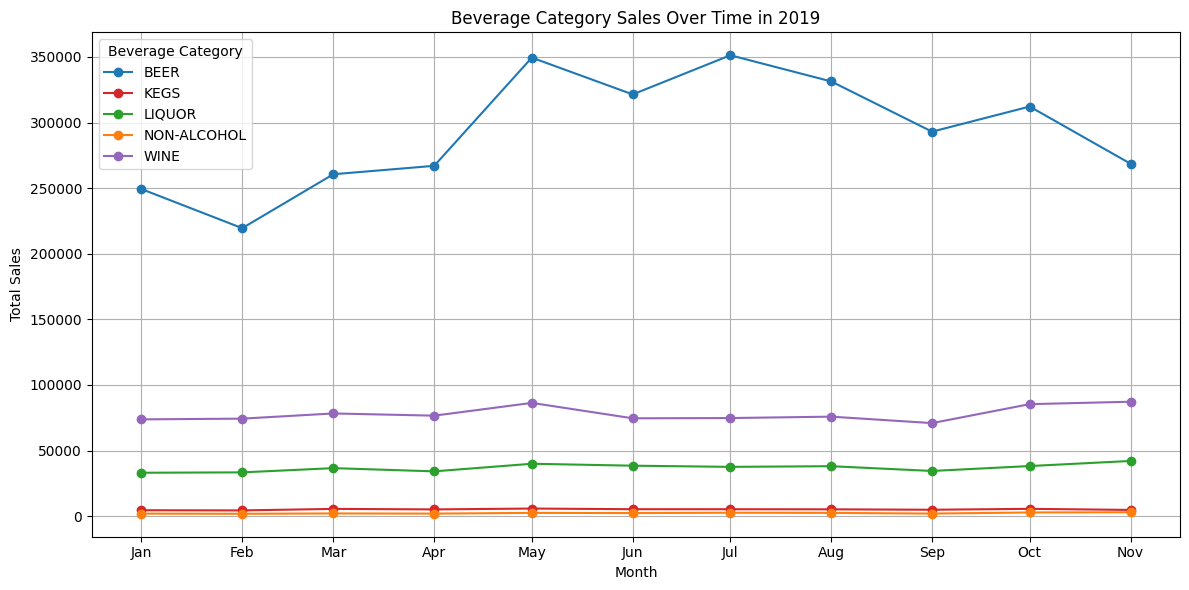

In [16]:
#3b question 2
import matplotlib.dates as mdates

category_colors = {
    "BEER": "tab:blue",
    "KEGS": "tab:red",
    "LIQUOR": "tab:green",
    "NON-ALCOHOL": "tab:orange",
    "WINE": "tab:purple"
}

plt.figure(figsize=(12, 6))

for category in beverage_types:
    plt.plot(
        category_sales_pivot.index,
        category_sales_pivot[category],
        marker="o",
        label=category,
        color=category_colors[category]
    )

plt.title("Beverage Category Sales Over Time in 2019")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b")
)

plt.legend(title="Beverage Category")
plt.grid(True)

plt.tight_layout()
plt.show()

## 3c Question 2 Interpretation.

The line graph shows the total beverage sales over time through January - November from the year 2019. Through this line graph we can clearly see a large gap between the beer sales and every other beverage category. One can see beer sales experience a dip of about 35,000 in sales from January to February. From February to May beer sales see a constant growth in sales, rising to its second highest selling month at 350,000 sales. From May to June beer takes a dip in sales of about 25,000 before rising back up to its peak of just over 350,000 sales in July. From July to September, there is a gradual decrease in sales at just under 300,000 in the month of Semptember. The beer sales then rise again to about 310,000 from September to October before decreasing again to about 265,000 in the month of November.

The chart shows that wine sales are the second highest amongst the beverage categories. The sales for wine mostly stayed consistent throughout the months of January to November. However, there were noticable peaks where wine sales rose to 80,000 - 90,000 in the months of May, October, and November. In all other months, there was little to no movement in wine sales as it stay around 70,000 - 75,000. 

The third highest selling category was liquor which also saw consistent sales over the months. From January to April the liquor sales were consistently around 35,000. In May, they were their second highest at about 45,000 before declining slightly in the coming months from June to September to about 38,000. There would be a gradual increase from September to October to aboiut 40,000 before eventually peaking in the month of November at around 48,000.

The fourth highest selling category was kegs. The kegs sales remained very consistent. During the months of January to November, keg sales hovered around 4,000 - 6,000 sales. This means that there was little to no fluctuation in keg sales. Non-alcohoic beverages shared the same results as the lowest selling beverage category. From the months of January to November the sales of non-alcoholic drinks hover around 1,900 - 3,050. This means that like the kegs sales, non-alcoholic beverage sales have little to no fuctuation. This makes their sales extremely consistent across the months of January to November for the year 2019.

## Exploratory Data Analysis and Interpretation of Question 3

In [17]:
#process Question 3

sales_types_over_time = (
    beverage_data_2019
    .groupby("DATE")[
        ["RETAIL SALES", "WAREHOUSE SALES"]
    ]
    .sum()
    .reset_index()
)

print(sales_types_over_time)

         DATE  RETAIL SALES  WAREHOUSE SALES
0  2019-01-01      75979.83        286848.25
1  2019-02-01      79996.89        253580.68
2  2019-03-01      84322.08        298961.72
3  2019-04-01      80225.25        304832.87
4  2019-05-01      94814.49        389386.58
5  2019-06-01      90699.23        351629.08
6  2019-07-01      90622.87        381092.48
7  2019-08-01      90496.49         362641.1
8  2019-09-01      81982.04        323475.02
9  2019-10-01      88065.19        356286.04
10 2019-11-01     101450.28        304358.44


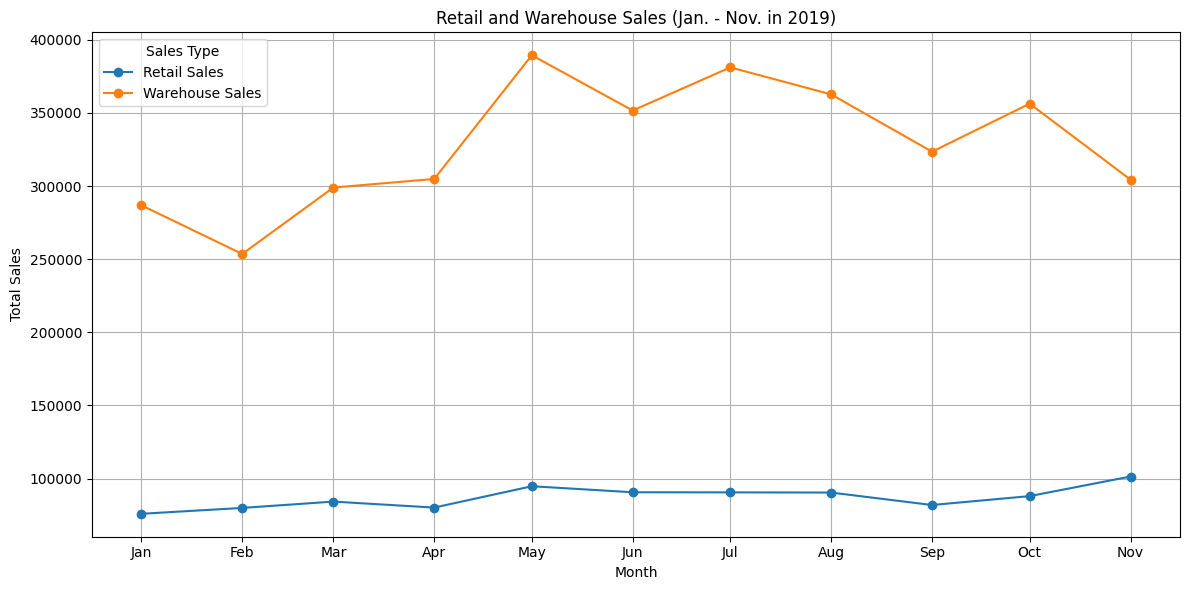

In [18]:
#3b question 3

plt.figure(figsize=(12, 6))

plt.plot(
    sales_types_over_time["DATE"],
    sales_types_over_time["RETAIL SALES"],
    marker="o",
    label="Retail Sales"
)

plt.plot(
    sales_types_over_time["DATE"],
    sales_types_over_time["WAREHOUSE SALES"],
    marker="o",
    label="Warehouse Sales"
)

plt.title("Retail and Warehouse Sales (Jan. - Nov. in 2019)")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b")
)

plt.legend(title="Sales Type")
plt.grid(True)

plt.tight_layout()
plt.show()

## 3c Question 3 Interpretation.

The line graph shows the difference between the two types of sales, retail and warhouse, over time for the months January to November for the year 2019.The line graph shows that warehouse sales greatly out weigh the retail sales. This is because warehouse sales typically sell in bulk and selling in bulk will combine a lot of individual products for higher price. From January to February the warehouse sales decrease from 285,000 - 255,000 in the month of February. From February to March there is an increase to about 300,000 sales. From March to April there is slight increase to 305,000 sales. From April to May there is a huge increase to about 385,000 sales. The month of May is where the warehouse sales peak for the months January to November. From May to June there is a noticable decrease to about 355,000 sales. There is another increase from June to July to about 375,000 sales. From July to August there is a steady decline to about 360,000 sales. This trend is continued from August to September in which the sales fall to about 325,000. From September to October there is another increase in sales to about 355,000. From October to November there is another decline in sales to about 305,000.

The retail sales exhibit way more consistent result then compared to the warehouse sales. From January to March the retail sales seen a slight increase of about 10,000 per month rising to 60,000 sales in the month of March. From March to April there was a slight decline to about 50,000 sales. A noticable increase would be seen from April to May to about 95,000 sales. From May to June there would be a slight decrease in retail sales to about 85,000 sales. From June to August the retail sales would remain very consistent with little fluctuation hovering in the 84,000 - 86,000 sales range. From August to September there would be another slight decrease to about 65,000. That decrease would be followed by an increase from September to October to about 75,000 sales. This upward trend would continue from October to November as the retail sales would peak at about 105,000.

## 4. Summary

This project looked at the warehouse and retail beverage sales from Montgomery County, Maryland. The analysis of this dataset aimed to identify the overall sales trend from a combination of the warehouse and retail sales. The results, over time, reveal a very consistant sales trend for retail sales and a overall increase in warehouse sales. These two trends can be seen as retail sales maintain a consistent 40,000 - 105,000 range, while the warehouse sales are almost always increasing from the initial 285,000 starting point at the first of the year. 

This project also reveals the total sale per beverage category throughout the year 2019. Beer is seen to dominate the sales creating a sizable gap in sales that seperate it from the other beverage categories. While being the most sold, beer is also the least consistent category as there is a upward trend of increased sales from April to August. The other beverage categories maintain a consistent sales range through the months of January to November and exhibit no large upward or downward trend in sales.

The top selling beverages per category where also identified through this data analysis. To no surprise, the top selling beer made up the most sales of the top selling beverages per category. The most popular beer was a corona brand beer that came in 12 ounces. The most popular vodka was from titos handmade vodka, coming in 1.75 liters. The most popular wine was from sutter home chard and came in 187 milliliters (roughly 6 ounces). The most popular keg was from millar lite and came in 15.5 gallons. The most popular non-alcoholic beverage came from goslings ginger beer, also coming in 12 ounces. Interestingly, three out of the five categories had their most popular beverages come in 6 - 12 ounces. This shows the popularity of the 6 - 12 ounce bottle option and the hold it has on the customers.

This dataset comes up short in the fact that most of the years are not fully complete. Most years were missing multiple month entries along with some missing data entries in the existing columns. This was of course handled through the cleaning process and was assigned a value of unknown. The lack of complete years and missing multiple months of data entries make it hard to determine a trend of the sales over time. This forced me to isolate the year with the most data entries which was 2019. With the limited data from only one year it was difficult to identify trends and see lasting increases and decreases in the data. To get more accurate results, one would need to gather more complete data in order to analyze the sales trend over multiple years instead of inside one year.